In [1]:
# Run first on Google Colab
!pip install qutip -q

# §2 Quantum Fourier Transform

**Course:** Introductory Quantum Computing — Summer School

## Learning objectives
- Implement the QFT from the product formula and verify unitarity
- Relate the QFT circuit to the classical Cooley–Tukey FFT
- Analyse the approximate QFT operator-norm truncation error vs the rotation cutoff

In [2]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

print(f"QuTiP {qt.__version__}")


QuTiP 5.3.0


In [3]:
# ── Standard single-qubit states and gates (used throughout §2) ─────────────
zero  = qt.basis(2, 0)           # |0⟩
one   = qt.basis(2, 1)           # |1⟩
plus  = (zero + one).unit()      # |+⟩
minus = (zero - one).unit()      # |−⟩

X  = qt.sigmax()
Y  = qt.sigmay()
Z  = qt.sigmaz()
I  = qt.qeye(2)
P0 = zero * zero.dag()           # |0⟩⟨0|
P1 = one  * one.dag()            # |1⟩⟨1|


---
## Part 2: Quantum Fourier Transform

### 2.1 Definition and unitarity

The **$n$-qubit QFT** is the DFT matrix acting on amplitudes:
$$\mathsf{QFT}_N|k\rangle = \frac{1}{\sqrt{N}}\sum_{j=0}^{N-1}\omega_N^{jk}|j\rangle, \qquad \omega_N = e^{2\pi i/N}, \quad N = 2^n$$

As a matrix: $(\mathsf{QFT}_N)_{jk} = \omega_N^{jk}/\sqrt{N}$.

**Unitarity:** $\mathsf{QFT}_N^\dagger\mathsf{QFT}_N = \mathbb{I}$ (columns are orthonormal — orthogonality of complex exponentials).


In [4]:
def qft_matrix(n):
    """n-qubit QFT as a QuTiP Qobj (DFT matrix on 2^n-dim space)."""
    N = 2**n
    omega = np.exp(2j * np.pi / N)
    F = np.array([[omega**(j*k) / np.sqrt(N) for k in range(N)] for j in range(N)])
    return qt.Qobj(F, dims=[[2]*n, [2]*n])

F2 = qft_matrix(2)   # 2-qubit QFT (4×4)
F3 = qft_matrix(3)   # 3-qubit QFT (8×8)

print("QFT_4 matrix (real parts):")
print(np.round(F2.full().real, 3))

# Unitarity
print("\nQFT†·QFT = I (n=2):", np.allclose((F2.dag()*F2).full(), np.eye(4)))
print("QFT†·QFT = I (n=3):", np.allclose((F3.dag()*F3).full(), np.eye(8)))

# Verify QFT_4|k> = (1/2) sum_j i^{jk} |j>  (since ω_4 = i)
# qt.basis(4,1) with dims [[2,2],[1,1]] represents the 2-qubit state |01⟩
ket01 = qt.basis(4, 1)
ket01.dims = [[2,2],[1,1]]
out = F2 * ket01
expected = np.array([1, 1j, -1, -1j]) / 2.0   # j=0..3, k=1: omega^j = i^j
print("\nQFT_4|01⟩ =", np.round(out.full().flatten(), 4))
print("expected   =", np.round(expected, 4))

QFT_4 matrix (real parts):
[[ 0.5  0.5  0.5  0.5]
 [ 0.5  0.  -0.5 -0. ]
 [ 0.5 -0.5  0.5 -0.5]
 [ 0.5 -0.  -0.5  0. ]]

QFT†·QFT = I (n=2): True
QFT†·QFT = I (n=3): True

QFT_4|01⟩ = [ 0.5+0.j   0. +0.5j -0.5+0.j  -0. -0.5j]
expected   = [ 0.5+0.j   0. +0.5j -0.5+0.j  -0. -0.5j]


### 2.2 The QFT circuit (product formula)

**Theorem (Product formula):**
$$\mathsf{QFT}_N|k_1 k_2\cdots k_n\rangle = \bigotimes_{l=1}^{n}\frac{1}{\sqrt{2}}\bigl(|0\rangle + e^{2\pi i\,[0.k_{n-l+1}\cdots k_n]_2}|1\rangle\bigr)$$

The output is a **tensor product** of single-qubit states — enabling an efficient qubit-by-qubit circuit.
Each qubit $l$ of the output depends only on the last $l$ bits of the input.

**Binary fraction notation:** $[0.b_1 b_2 \cdots b_m]_2 = \frac{b_1}{2} + \frac{b_2}{4} + \cdots + \frac{b_m}{2^m}$.
For example, $[0.k_2]_2 = k_2/2$ and $[0.k_1 k_2]_2 = k_1/2 + k_2/4$.

**Circuit:** For qubit $i$ (0-indexed):
1. Apply $\mathsf{H}$
2. For each later qubit $j > i$: apply controlled-$\mathsf{R}_{j-i+1}$ (control = $j$, target = $i$)

Then reverse qubit order with $\lfloor n/2\rfloor$ SWAPs.
Total gates: $\frac{n(n+1)}{2} + \lfloor n/2\rfloor = O(n^2)$.

Where $\mathsf{R}_m = \mathrm{diag}(1, e^{2\pi i/2^m})$ adds a phase of $e^{2\pi i/2^m}$ to $|1\rangle$.

In [5]:
# ── Helper: apply single-qubit gate to qubit i in n-qubit system ──────────────
def apply_to_qubit(gate, n, qubit):
    ops = [qt.qeye(2)] * n
    ops[qubit] = gate
    return qt.tensor(ops)

# ── Helper: controlled-U (control=ctrl, target=tgt) in n-qubit system ─────────
def controlled_u(U, n, ctrl, tgt):
    P0 = qt.basis(2,0) * qt.basis(2,0).dag()
    P1 = qt.basis(2,1) * qt.basis(2,1).dag()
    ops0 = [qt.qeye(2)] * n;  ops0[ctrl] = P0
    ops1 = [qt.qeye(2)] * n;  ops1[ctrl] = P1;  ops1[tgt] = U
    return qt.tensor(ops0) + qt.tensor(ops1)

# ── Helper: SWAP gate between qubits i and j ──────────────────────────────────
def swap_gate(n, i, j):
    N = 2**n
    mat = np.zeros((N, N), dtype=complex)
    for k in range(N):
        bits = list(format(k, f'0{n}b'))
        bits[i], bits[j] = bits[j], bits[i]
        mat[int(''.join(bits), 2), k] = 1.0
    return qt.Qobj(mat, dims=[[2]*n, [2]*n])

# ── QFT circuit ───────────────────────────────────────────────────────────────
def qft_circuit(n):
    """Build QFT_N from the product formula circuit."""
    dims = [[2]*n, [2]*n]
    U = qt.tensor([qt.qeye(2)] * n)
    H1 = qt.gates.hadamard_transform(1)
    for i in range(n):
        U = apply_to_qubit(H1, n, i) * U
        for j in range(i+1, n):
            m = j - i + 1
            Rm = qt.Qobj(np.diag([1.0, np.exp(2j*np.pi/2**m)]))
            U = controlled_u(Rm, n, j, i) * U
    for i in range(n // 2):
        U = swap_gate(n, i, n-1-i) * U
    return U

print("Building QFT circuits...")
Fc2 = qft_circuit(2)
Fc3 = qft_circuit(3)
print("Done.")


Building QFT circuits...
Done.


Circuit = DFT matrix (n=2): True
Circuit = DFT matrix (n=3): True

QFT|5⟩ via circuit and matrix agree: True


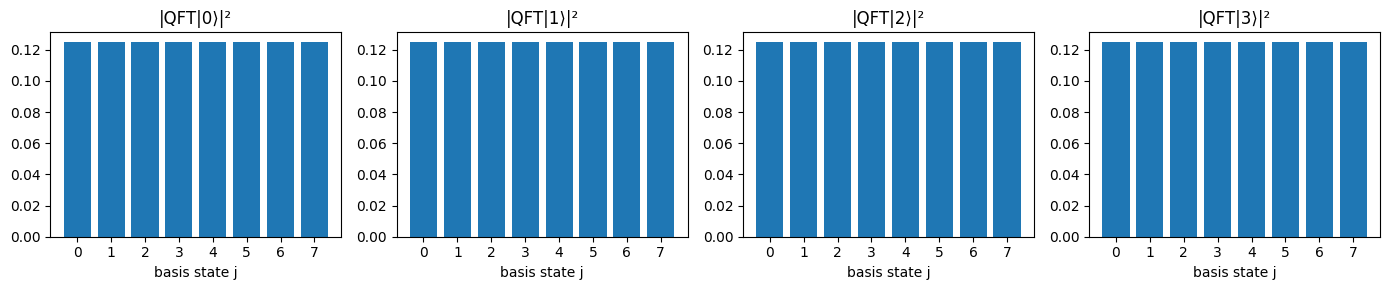

In [6]:
# Verify circuit == exact DFT matrix
print("Circuit = DFT matrix (n=2):", np.allclose(Fc2.full(), F2.full()))
print("Circuit = DFT matrix (n=3):", np.allclose(Fc3.full(), F3.full()))

# Trace through n=3 circuit for |k> = |101> (k=5)
k_val = 5
ket_k = qt.basis(8, k_val);  ket_k.dims = [[2,2,2],[1,1,1]]
out_circ = Fc3 * ket_k
out_dft  = F3  * ket_k

print(f"\nQFT|{k_val}⟩ via circuit and matrix agree:", np.allclose(out_circ.full(), out_dft.full()))

# Visualise |QFT|k>|^2 for all k
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for k_test in range(4):
    ket = qt.basis(8, k_test);  ket.dims = [[2,2,2],[1,1,1]]
    probs = np.abs((F3 * ket).full().flatten())**2
    axes[k_test].bar(range(8), probs)
    axes[k_test].set_title(f"|QFT|{k_test}⟩|²")
    axes[k_test].set_xlabel("basis state j")
    axes[k_test].set_xticks(range(8))
plt.tight_layout()
plt.show()


### 2.3 QFT diagonalises the cyclic shift

The **cyclic shift** operator $\hat{X}|k\rangle = |k+1 \bmod N\rangle$ is the quantum analogue of the derivative operator (or circulant shift).

The QFT diagonalises $\hat{X}$:
$$\mathsf{QFT}_N^\dagger\,\hat{X}\,\mathsf{QFT}_N = \hat{Z}^{-1},$$
where $\hat{Z}|k\rangle = \omega_N^k|k\rangle$ is multiplication by $\omega_N^k$ in the Fourier basis.

The eigenvectors of $\hat{X}$ are the QFT basis states $\mathsf{QFT}_N^\dagger|j\rangle$, with eigenvalues $\omega_N^j$.


In [7]:
n = 3;  N = 2**n

# Build cyclic shift X_hat: |k> -> |(k+1) mod N>
shift_mat = np.zeros((N, N))
for k in range(N):
    shift_mat[(k+1) % N, k] = 1.0
Xhat = qt.Qobj(shift_mat, dims=[[2]*n, [2]*n])

# Build diagonal phase operator Z_hat: |k> -> omega^k |k>
omega = np.exp(2j * np.pi / N)
Zhat = qt.Qobj(np.diag([omega**k for k in range(N)]), dims=[[2]*n, [2]*n])

# Verify QFT† X_hat QFT = Z_hat^{-1}
lhs = F3.dag() * Xhat * F3
rhs = Zhat.dag()   # Z_hat^{-1} = Z_hat†
print("QFT† X̂ QFT = Ẑ⁻¹:", np.allclose(lhs.full(), rhs.full()))

# Verify eigenvectors of X_hat are QFT columns
evals, evecs = Xhat.eigenstates()
print("\nEigenvalues of cyclic shift (should be ω^j for j=0..7):")
print(np.round(sorted(evals), 3))
expected_evals = sorted([omega**j for j in range(N)])
print("Expected:", np.round(expected_evals, 3))


QFT† X̂ QFT = Ẑ⁻¹: True

Eigenvalues of cyclic shift (should be ω^j for j=0..7):
[-1.   +0.j    -0.707+0.707j -0.707-0.707j  0.   +1.j     0.   -1.j
  0.707+0.707j  0.707-0.707j  1.   +0.j   ]
Expected: [-1.   +0.j    -0.707-0.707j -0.707+0.707j -0.   -1.j     0.   +1.j
  0.707-0.707j  0.707+0.707j  1.   +0.j   ]


### Exercise 2.3 — QFT₄ by hand

**(a)** Apply $\mathsf{QFT}_4$ to $|1\rangle$ and $|2\rangle$ using the product formula.
Express each result as a tensor product of single-qubit states $\frac{1}{\sqrt{2}}(|0\rangle + e^{i\phi}|1\rangle)$ for appropriate $\phi$.

**(b)** Verify using the matrix definition that $\mathsf{QFT}_4|k\rangle = \frac{1}{2}\sum_{j=0}^{3}i^{jk}|j\rangle$.


In [8]:
# YOUR CODE HERE

# (a) Apply QFT_4 to |1> and |2> using the product formula
# For |k> = |k1 k2>, the product formula gives:
#   QFT_4|k> = (1/sqrt(2))(|0>+e^{2πi[0.k2]}|1>) ⊗ (1/sqrt(2))(|0>+e^{2πi[0.k1k2]}|1>)
# Then swap the two output qubits.

# ket1_manual = ...   (build manually from product formula for k=1=[01]_2)
# ket2_manual = ...   (for k=2=[10]_2)

# (b) Verify with matrix
F_4 = qft_matrix(2)
# ket1 = qt.basis(4,1); ket1.dims = [[2,2],[1,1]]
# out = F_4 * ket1
# expected = ...


In [9]:
#@title Solution — Exercise 2.3  {display-mode: "form"}
F_4 = qft_matrix(2)

# ── (a) QFT_4 applied to |01⟩ (k=1=[k1,k2]=[0,1]) by product formula ────────
# After the bit-reversal SWAP, the output is:
#   MSB qubit: (1/√2)(|0⟩ + e^{2πi[0.k2]_2}|1⟩)   ← phase depends only on k2
#   LSB qubit: (1/√2)(|0⟩ + e^{2πi[0.k1k2]_2}|1⟩)  ← phase depends on k1 and k2
#
# k=1=[0,1]: [0.k2]=0.5 → e^{πi}=-1  and  [0.k1k2]=0.25 → e^{πi/2}=i
q_msb_k1 = (zero + np.exp(1j*np.pi    )*one).unit()  # MSB: (|0⟩-|1⟩)/√2
q_lsb_k1 = (zero + np.exp(1j*np.pi/2  )*one).unit()  # LSB: (|0⟩+i|1⟩)/√2
ket1_manual = qt.tensor(q_msb_k1, q_lsb_k1)

ket1 = qt.basis(4, 1);  ket1.dims = [[2,2],[1,1]]
out1 = F_4 * ket1
print("QFT_4|01⟩ manual:", np.round(ket1_manual.full().flatten(), 4))
print("QFT_4|01⟩ matrix:", np.round(out1.full().flatten(), 4))
print("Match k=1:", np.allclose(ket1_manual.full(), out1.full()))

# k=2=[1,0]: [0.k2]=0 → e^0=1  and  [0.k1k2]=0.5 → e^{πi}=-1
q_msb_k2 = (zero + one                 ).unit()       # MSB: (|0⟩+|1⟩)/√2 = |+⟩
q_lsb_k2 = (zero + np.exp(1j*np.pi    )*one).unit()  # LSB: (|0⟩-|1⟩)/√2 = |−⟩
ket2_manual = qt.tensor(q_msb_k2, q_lsb_k2)

ket2 = qt.basis(4, 2);  ket2.dims = [[2,2],[1,1]]
out2 = F_4 * ket2
print("\nQFT_4|10⟩ manual:", np.round(ket2_manual.full().flatten(), 4))
print("QFT_4|10⟩ matrix:", np.round(out2.full().flatten(), 4))
print("Match k=2:", np.allclose(ket2_manual.full(), out2.full()))

# ── (b) Verify QFT_4|k⟩ = (1/2) Σ_j i^{jk} |j⟩ ─────────────────────────────
print()
for k in range(4):
    ket_k = qt.basis(4, k);  ket_k.dims = [[2,2],[1,1]]
    out   = F_4 * ket_k
    exp   = np.array([1j**(j*k) for j in range(4)]) / 2.0
    print(f"k={k}: match = {np.allclose(out.full().flatten(), exp)}")

QFT_4|01⟩ manual: [ 0.5+0.j   0. +0.5j -0.5+0.j  -0. -0.5j]
QFT_4|01⟩ matrix: [ 0.5+0.j   0. +0.5j -0.5+0.j  -0. -0.5j]
Match k=1: True

QFT_4|10⟩ manual: [ 0.5+0.j -0.5+0.j  0.5+0.j -0.5+0.j]
QFT_4|10⟩ matrix: [ 0.5+0.j -0.5+0.j  0.5-0.j -0.5+0.j]
Match k=2: True

k=0: match = True
k=1: match = True
k=2: match = True
k=3: match = True


### 2.4 Approximate QFT

**Definition:** Drop all controlled-$\mathsf{R}_m$ gates with $m > m_{\max}$.
Uses $O(n\, m_{\max})$ gates instead of $O(n^2)$.

**Theorem (error bound):**
$$\|\mathsf{QFT} - \mathsf{QFT}_{m_{\max}}\|_{\mathrm{op}} \leq \frac{2\pi n}{2^{m_{\max}}}$$

where $\|\cdot\|_{\mathrm{op}}$ is the operator (spectral) norm — the largest singular value.
Choosing $m_{\max} = \lceil\log_2(2\pi n/\varepsilon)\rceil$ guarantees operator-norm error $\leq \varepsilon$ with $O(n\log(n/\varepsilon))$ gates.

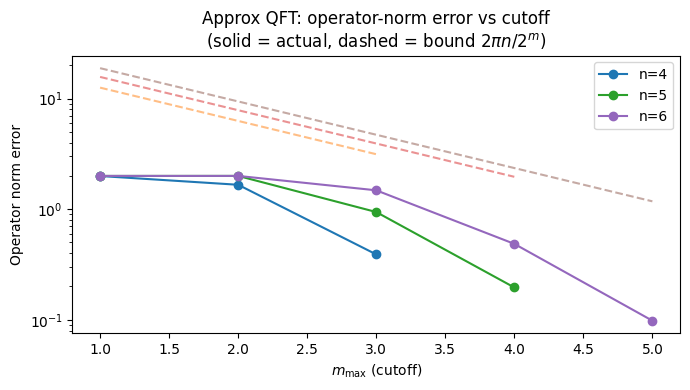

In [10]:
def qft_circuit_approx(n, m_max):
    """Approximate QFT: drop controlled-R_m gates with m > m_max."""
    U = qt.tensor([qt.qeye(2)] * n)
    H1 = qt.gates.hadamard_transform(1)
    for i in range(n):
        U = apply_to_qubit(H1, n, i) * U
        for j in range(i+1, n):
            m = j - i + 1
            if m <= m_max:
                Rm = qt.Qobj(np.diag([1.0, np.exp(2j*np.pi/2**m)]))
                U = controlled_u(Rm, n, j, i) * U
    for i in range(n // 2):
        U = swap_gate(n, i, n-1-i) * U
    return U

# ── Operator-norm error vs m_max for n = 4, 5, 6 ─────────────────────────────
# The bound 2πn/2^m is for the OPERATOR norm (largest singular value),
# not the Frobenius norm. We exclude m_max = n (exact QFT, trivial error).
fig, ax = plt.subplots(figsize=(7, 4))

for n_test in [4, 5, 6]:
    F_exact = qft_matrix(n_test)
    m_vals  = list(range(1, n_test))       # exclude last point (exact QFT)
    errors  = []
    for m in m_vals:
        diff = (F_exact - qft_circuit_approx(n_test, m)).full()
        errors.append(np.linalg.norm(diff, ord=2))   # operator norm
    ax.semilogy(m_vals, errors, 'o-', label=f'n={n_test}')
    bounds = [2*np.pi*n_test / 2**m for m in m_vals]
    ax.semilogy(m_vals, bounds, '--', alpha=0.5)

ax.set_xlabel('$m_{\\max}$ (cutoff)')
ax.set_ylabel('Operator norm error')
ax.set_title('Approx QFT: operator-norm error vs cutoff\n(solid = actual, dashed = bound $2\\pi n/2^m$)')
ax.legend()
plt.tight_layout()
plt.show()

### Exercise 2.4 — Approximate QFT error vs cutoff

The operator-norm bound guarantees $\|\mathsf{QFT} - \mathsf{QFT}_{m_{\max}}\|_{\mathrm{op}} \leq \dfrac{2\pi n}{2^{m_{\max}}}$.

**(a)** For $n = 8$ and $\varepsilon \in \{2.0,\, 1.0,\, 0.5\}$, derive the minimum $m_{\max}$ satisfying the bound analytically.

**(b)** For each $m_{\max}$, measure the actual operator-norm error and verify the bound holds.

**(c)** Check whether $m_{\max} - 1$ also achieves error $< \varepsilon$ in practice. Is the bound tight?

In [11]:
# YOUR CODE HERE

import math

n = 8
epsilons = [2.0, 1.0, 0.5]

# (a) Minimum m_max from the bound: 2*pi*n / 2**m <= eps  →  m >= ceil(log2(2*pi*n/eps))
# m_min = ...

# (b) Actual operator-norm error at m_min: np.linalg.norm(diff, ord=2)
# ...

# (c) Check m_min - 1; comment on whether the bound is tight
# ...

In [12]:
#@title Solution — Exercise 2.4  {display-mode: "form"}
import math

n        = 8
F_exact  = qft_matrix(n)
epsilons = [2.0, 1.0, 0.5]

print(f"n = {n}")
print(f"{'eps':>5}  {'m_min':>6}  {'err(m_min)':>12}  {'bound':>8}  {'holds?':>7}  {'err(m_min-1)':>14}  {'tight?':>7}")
print('-' * 72)
for eps in epsilons:
    # (a) smallest m satisfying 2*pi*n / 2**m <= eps
    m_min  = math.ceil(math.log2(2 * math.pi * n / eps))
    bound  = 2 * math.pi * n / 2**m_min

    # (b) actual operator-norm error at m_min
    err_m  = np.linalg.norm((F_exact - qft_circuit_approx(n, m_min)).full(), ord=2)

    # (c) error at m_min - 1
    err_m1 = np.linalg.norm((F_exact - qft_circuit_approx(n, m_min-1)).full(), ord=2)

    print(f"{eps:>5.1f}  {m_min:>6d}  {err_m:>12.4f}  {bound:>8.4f}  {'✓' if err_m<=eps else '✗':>7}  {err_m1:>14.4f}  {'✗ (loose)' if err_m1<=eps else '✓ (tight)':>9}")

print("""
Observation: the bound holds at m_min, but m_min-1 also achieves error < ε
in every case. The bound 2πn/2^m is provably valid but conservative —
it over-estimates the number of gates needed by several levels.
In practice, far fewer rotations are needed than the bound suggests.""")

n = 8
  eps   m_min    err(m_min)     bound   holds?    err(m_min-1)   tight?
------------------------------------------------------------------------
  2.0       5        0.4142    1.5708        ✓          1.1315  ✗ (loose)
  1.0       6        0.1226    0.7854        ✓          0.4142  ✗ (loose)
  0.5       7        0.0245    0.3927        ✓          0.1226  ✗ (loose)

Observation: the bound holds at m_min, but m_min-1 also achieves error < ε
in every case. The bound 2πn/2^m is provably valid but conservative —
it over-estimates the number of gates needed by several levels.
In practice, far fewer rotations are needed than the bound suggests.


---
## Summary

| Topic | Key result |
|-------|-----------|
| QFT definition | $\mathsf{QFT}_N|k\rangle = \frac{1}{\sqrt{N}}\sum_{j=0}^{N-1}\omega_N^{jk}|j\rangle$; unitary (DFT on amplitudes) |
| QFT circuit | $O(n^2)$ gates via product formula; controlled-$\mathsf{R}_m$ gates + bit-reversal SWAPs |
| Cyclic shift | $\mathsf{QFT}^\dagger\,\hat{X}\,\mathsf{QFT} = \hat{Z}^{-1}$; QFT diagonalises the cyclic shift operator |
| Approximate QFT | Drop gates with $m > m_{\max}$; operator-norm error $\leq \frac{2\pi n}{2^{m_{\max}}}$; $O(n\log(n/\varepsilon))$ gates |

**Next:** Notebook 3 applies the QFT as a subroutine in Quantum Phase Estimation (§3).